In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [39]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [40]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [41]:
print(df.shape)

(10000, 14)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [43]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [44]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)
# This is done to encode categorical variables altogether and also drop first means creating n-1 columns with n categorical values

In [45]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [46]:
# Scaling values in the estimated salary and balance column 
X=df.drop(columns=['Exited'])
Y=df['Exited']
from sklearn.model_selection import train_test_split 
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

In [47]:
X_train.shape

(8000, 11)

In [49]:
from sklearn.preprocessing import StandardScaler 
SS=StandardScaler()

X_train_scaled=SS.fit_transform(X_train)
X_test_scaled=SS.transform(X_test)

In [50]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [52]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-05-23 08:07:00.924751: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779523621.163374      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779523621.235605      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779523621.784650      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779523621.784709      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779523621.784712      57 computation_placer.cc:177] computation placer alr

In [53]:
model=Sequential()

# Creating input layer
model.add(Dense(3,activation='sigmoid',input_dim=11))
# Input columns are 11 
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-23 08:09:27.683251: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Since this is a binary classification problem we would be using binary Crossentropy as loss function 
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [57]:
model.fit(X_train_scaled,Y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6828
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5532
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4943
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4726
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4667
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4515
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4469
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4653
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4299
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4243


In [59]:
model.layers[0].get_weights()
# The 33 weights since 11 input params and 3 inner nodes so 33 and below it are it's weight

[array([[ 0.38114262,  0.10168341, -0.16942377],
        [-1.1027496 , -2.0077782 , -0.09065001],
        [ 0.30942816, -0.02922136,  0.34929383],
        [-0.501271  , -0.32830456, -0.20374973],
        [ 0.59438866,  0.00734376, -0.4676125 ],
        [ 0.02232429, -0.00747634, -0.02701407],
        [ 0.60135186,  0.72601974,  0.23175605],
        [ 0.07533409, -0.07882573,  0.0235708 ],
        [-0.34932297, -0.71397865, -0.1963592 ],
        [ 0.11191095, -0.06700047,  0.4949442 ],
        [ 0.6070492 ,  0.5099019 , -0.48266676]], dtype=float32),
 array([ 0.03344807,  0.47708428, -0.273861  ], dtype=float32)]

In [60]:
model.layers[1].get_weights()

[array([[-0.44070834],
        [-1.6048867 ],
        [ 0.02434961]], dtype=float32),
 array([-0.40315706], dtype=float32)]

In [69]:
y=model.predict(X_test_scaled) 
y
# The output is not 0 or 1 because the output is in sigmoid form

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.13693063],
       [0.1389377 ],
       [0.1506946 ],
       ...,
       [0.08737148],
       [0.14359826],
       [0.3529546 ]], dtype=float32)

In [70]:
# Threshold should be set up to get binary prediction
y_pred=np.where(y>0.5,1,0)

In [71]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [72]:
from sklearn.metrics import accuracy_score 
accuracy_score(Y_test,y_pred)

0.7925

In [73]:
# Changing model hyperparams for testing again 
model1=Sequential()
model1.add(Dense(11,activation='relu',input_dim=11))
model1.add(Dense(11,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122 (492.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82 (332.00 B)

In [85]:
model1.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [90]:
history=model1.fit(X_train_scaled,Y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8696 - loss: 0.3092 - val_accuracy: 0.8612 - val_loss: 0.3365
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8757 - loss: 0.3003 - val_accuracy: 0.8637 - val_loss: 0.3339
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3173 - val_accuracy: 0.8612 - val_loss: 0.3355
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8699 - loss: 0.3032 - val_accuracy: 0.8619 - val_loss: 0.3340
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8786 - loss: 0.3079 - val_accuracy: 0.8612 - val_loss: 0.3379
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8689 - loss: 0.3145 - val_accuracy: 0.8631 - val_loss: 0.3354
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8736 - loss: 0.3024 - val_accuracy: 0.8612 - val_loss: 0.3362
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3062 - val_accu

In [87]:
y1=model1.predict(X_test_scaled)
y1

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.01828204],
       [0.13206433],
       [0.0569833 ],
       ...,
       [0.00685286],
       [0.03539469],
       [0.36549994]], dtype=float32)

In [88]:
y1_pred=np.where(y1>0.5,1,0)

In [89]:
accuracy_score(Y_test,y1_pred)

0.865

In [91]:
import matplotlib.pyplot as plt

In [93]:
history.history

{'accuracy': [0.8706250190734863,
  0.8704687356948853,
  0.8696874976158142,
  0.8698437213897705,
  0.8721874952316284,
  0.8704687356948853,
  0.8706250190734863,
  0.8706250190734863,
  0.8700000047683716,
  0.8704687356948853,
  0.8707812428474426,
  0.8715624809265137,
  0.87109375,
  0.8712499737739563,
  0.8701562285423279,
  0.8704687356948853,
  0.8695312738418579,
  0.8707812428474426,
  0.8706250190734863,
  0.8712499737739563,
  0.870312511920929,
  0.8693749904632568,
  0.8709375262260437,
  0.8701562285423279,
  0.8689062595367432,
  0.8709375262260437,
  0.8695312738418579,
  0.8717187643051147,
  0.8709375262260437,
  0.8689062595367432,
  0.8712499737739563,
  0.87109375,
  0.8696874976158142,
  0.8714062571525574,
  0.8712499737739563,
  0.8712499737739563,
  0.8692187666893005,
  0.8717187643051147,
  0.8715624809265137,
  0.8701562285423279,
  0.8701562285423279,
  0.8721874952316284,
  0.8723437786102295,
  0.8706250190734863,
  0.8707812428474426,
  0.87296873331

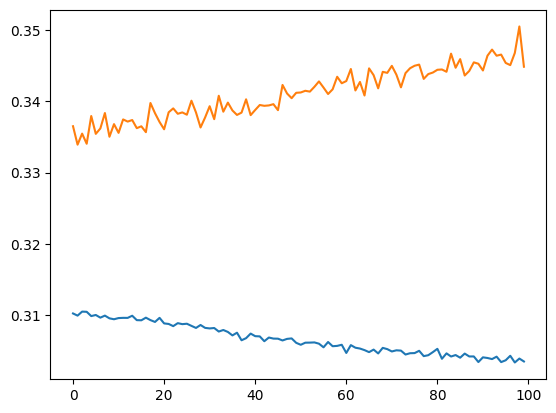

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

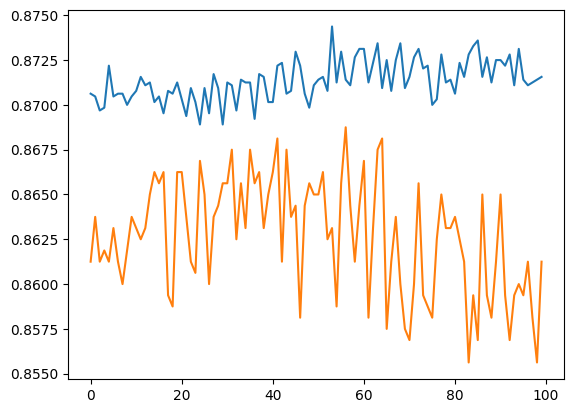

In [96]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])